In [2]:
import cv2
import numpy as np
import os 
from matplotlib import pyplot as plt
import mediapipe as mp

In [3]:
mp_holistic = mp.solutions.holistic #bringing in a holistic model
mp_drawing = mp.solutions.drawing_utils #Drawing utilities

In [4]:
def mediapipe_detection(image, model): #this model is mediapipe holistic model
    image = cv2.cvtColor(image , cv2.COLOR_BGR2RGB)  #colour conversion
    image.setflags(write=False)   #to save space
    results = model.process(image)  #actual detection by mediapipe or prediction
    image.setflags(write =True)
    image = cv2.cvtColor(image , cv2.COLOR_RGB2BGR)
    return image , results

In [5]:
cv2.cvtColor?
 #gives description about the above one

Docstring:
cvtColor(src, code[, dst[, dstCn[, hint]]]) -> dst
.   @brief Converts an image from one color space to another.
.   
.   The function converts an input image from one color space to another. In case of a transformation
.   to-from RGB color space, the order of the channels should be specified explicitly (RGB or BGR). Note
.   that the default color format in OpenCV is often referred to as RGB but it is actually BGR (the
.   bytes are reversed). So the first byte in a standard (24-bit) color image will be an 8-bit Blue
.   component, the second byte will be Green, and the third byte will be Red. The fourth, fifth, and
.   sixth bytes would then be the second pixel (Blue, then Green, then Red), and so on.
.   
.   The conventional ranges for R, G, and B channel values are:
.   -   0 to 255 for CV_8U images
.   -   0 to 65535 for CV_16U images
.   -   0 to 1 for CV_32F images
.   
.   In case of linear transformations, the range does not matter. But in case of a non-linear
.  

In [6]:
# def draw_landmarks(image, results):
#     mp_drawing.draw_landmarks(image , results.face_landmarks , mp_holistic.FACEMESH_CONTOURS)
#     mp_drawing.draw_landmarks(image , results.pose_landmarks , mp_holistic.POSE_CONNECTIONS)
#     mp_drawing.draw_landmarks(image , results.right_hand_landmarks , mp_holistic.HAND_CONNECTIONS)
#     mp_drawing.draw_landmarks(image, results.left_hand_landmarks , mp_holistic.HAND_CONNECTIONS )

In [7]:
def draw_styled_landmarks(image, results):
    # Draw face connections
    mp_drawing.draw_landmarks(
        image, results.face_landmarks, mp_holistic.FACEMESH_TESSELATION,
        mp_drawing.DrawingSpec(color=(80, 110, 10), thickness=1, circle_radius=1),
        mp_drawing.DrawingSpec(color=(80, 256, 121), thickness=1, circle_radius=1)
    )
    # Draw pose connections
    mp_drawing.draw_landmarks(
        image, results.pose_landmarks, mp_holistic.POSE_CONNECTIONS,
        mp_drawing.DrawingSpec(color=(80, 22, 10), thickness=1, circle_radius=1),
        mp_drawing.DrawingSpec(color=(80, 44, 121), thickness=1, circle_radius=1)
    )
    # Draw right hand connections
    mp_drawing.draw_landmarks(
        image, results.right_hand_landmarks, mp_holistic.HAND_CONNECTIONS,
        mp_drawing.DrawingSpec(color=(80, 54, 10), thickness=1, circle_radius=1),
        mp_drawing.DrawingSpec(color=(80, 108, 121), thickness=1, circle_radius=1)
    )
    # Draw left hand connections
    mp_drawing.draw_landmarks(
        image, results.left_hand_landmarks, mp_holistic.HAND_CONNECTIONS,
        mp_drawing.DrawingSpec(color=(80, 54, 10), thickness=1, circle_radius=1),
        mp_drawing.DrawingSpec(color=(80, 108, 121), thickness=1, circle_radius=1)
    )

In [8]:
mp_pose = mp.solutions.pose

#Print all connections with names

for connection in mp_holistic.POSE_CONNECTIONS:
    start = mp_pose.PoseLandmark(connection[0]).name
    end = mp_pose.PoseLandmark(connection[1]).name
    print(f"{connection[0]} {start} --> {connection[1]} {end}")

15 LEFT_WRIST --> 21 LEFT_THUMB
16 RIGHT_WRIST --> 20 RIGHT_INDEX
18 RIGHT_PINKY --> 20 RIGHT_INDEX
3 LEFT_EYE_OUTER --> 7 LEFT_EAR
14 RIGHT_ELBOW --> 16 RIGHT_WRIST
23 LEFT_HIP --> 25 LEFT_KNEE
28 RIGHT_ANKLE --> 30 RIGHT_HEEL
11 LEFT_SHOULDER --> 23 LEFT_HIP
27 LEFT_ANKLE --> 31 LEFT_FOOT_INDEX
6 RIGHT_EYE_OUTER --> 8 RIGHT_EAR
15 LEFT_WRIST --> 17 LEFT_PINKY
24 RIGHT_HIP --> 26 RIGHT_KNEE
16 RIGHT_WRIST --> 22 RIGHT_THUMB
4 RIGHT_EYE_INNER --> 5 RIGHT_EYE
5 RIGHT_EYE --> 6 RIGHT_EYE_OUTER
29 LEFT_HEEL --> 31 LEFT_FOOT_INDEX
12 RIGHT_SHOULDER --> 24 RIGHT_HIP
23 LEFT_HIP --> 24 RIGHT_HIP
0 NOSE --> 1 LEFT_EYE_INNER
9 MOUTH_LEFT --> 10 MOUTH_RIGHT
1 LEFT_EYE_INNER --> 2 LEFT_EYE
0 NOSE --> 4 RIGHT_EYE_INNER
11 LEFT_SHOULDER --> 13 LEFT_ELBOW
30 RIGHT_HEEL --> 32 RIGHT_FOOT_INDEX
28 RIGHT_ANKLE --> 32 RIGHT_FOOT_INDEX
15 LEFT_WRIST --> 19 LEFT_INDEX
16 RIGHT_WRIST --> 18 RIGHT_PINKY
25 LEFT_KNEE --> 27 LEFT_ANKLE
26 RIGHT_KNEE --> 28 RIGHT_ANKLE
12 RIGHT_SHOULDER --> 14 RIGHT_ELBOW
17 

In [9]:
cap = cv2.VideoCapture(0)
frame_count = 0

with mp_holistic.Holistic(
    min_detection_confidence = 0.5 , 
    min_tracking_confidence = 0.5,
    model_complexity = 0
) as holistic:
    while cap.isOpened():
        ret , frame = cap.read()
        if not ret:
            break

        frame_count+=1

        #Force redetection every 30 frames

        if frame_count %30 ==0:
            holistic = mp_holistic.Holistic(
                min_detection_confidence = 0.5,
                min_tracking_confidence = 0.5 , 
                model_complexity = 0
            ) 

        image, results = mediapipe_detection(frame , holistic)

        #Draw landmarks
        draw_styled_landmarks(image, results)

        print("Left: " , results.left_hand_landmarks)
        print("RIght: " , results.right_hand_landmarks)

        #Show to screen
        cv2.imshow('Feed' , image)

        #Break 
        if cv2.waitKey(10) & 0xFF == ord('N'):
            break

cap.release()
cv2.destroyAllWindows()        

Left:  None
RIght:  None
Left:  None
RIght:  None
Left:  None
RIght:  None
Left:  None
RIght:  None
Left:  None
RIght:  None
Left:  None
RIght:  None
Left:  None
RIght:  None
Left:  None
RIght:  None
Left:  None
RIght:  None
Left:  None
RIght:  None
Left:  None
RIght:  None
Left:  None
RIght:  None
Left:  None
RIght:  None
Left:  None
RIght:  None
Left:  None
RIght:  None
Left:  None
RIght:  None
Left:  None
RIght:  None
Left:  None
RIght:  None
Left:  None
RIght:  None
Left:  None
RIght:  None
Left:  None
RIght:  None
Left:  None
RIght:  None
Left:  None
RIght:  None
Left:  None
RIght:  None
Left:  None
RIght:  None
Left:  None
RIght:  None
Left:  None
RIght:  None
Left:  None
RIght:  None
Left:  None
RIght:  None
Left:  None
RIght:  None
Left:  None
RIght:  None
Left:  None
RIght:  None
Left:  None
RIght:  None
Left:  None
RIght:  None
Left:  None
RIght:  None
Left:  None
RIght:  None
Left:  None
RIght:  None
Left:  None
RIght:  None
Left:  None
RIght:  None
Left:  None
RIght:  None


In [10]:
if results.left_hand_landmarks:
    print(len(results.left_hand_landmarks.landmark))
else:
    print("Left hand not detected")

# Right hand
if results.right_hand_landmarks:
    print(len(results.right_hand_landmarks.landmark))
else:
    print("Right hand not detected")


if results.face_landmarks: 
    print(len(results.face_landmarks.landmark))
else : 
    print("Face not detected")

Left hand not detected
Right hand not detected
468


In [11]:
results.pose_landmarks.landmark[0].visibility

0.9997729659080505

In [12]:
# pose.flatten()  flatten just gives ytou a single set rather than multiple sets
# # pose.shape

In [13]:
pose = []
for res in results.pose_landmarks.landmark : 
    test=np.array([res.x, res.y , res.z , res.visibility])
pose.append(test)

In [14]:
pose = np.array([[res.x  , res.y , res.z , res.visibility] for res in results.pose_landmarks.landmark])
pose

array([[ 5.54702103e-01,  6.30845487e-01, -1.26235914e+00,
         9.99772966e-01],
       [ 5.80049932e-01,  5.59231639e-01, -1.17637575e+00,
         9.99639750e-01],
       [ 5.99460363e-01,  5.57183266e-01, -1.17575192e+00,
         9.99639511e-01],
       [ 6.15912735e-01,  5.55861354e-01, -1.17534935e+00,
         9.99541521e-01],
       [ 5.17700255e-01,  5.62677622e-01, -1.18919134e+00,
         9.99701917e-01],
       [ 4.95249212e-01,  5.63898802e-01, -1.18898880e+00,
         9.99731719e-01],
       [ 4.72700298e-01,  5.65459132e-01, -1.18921685e+00,
         9.99685884e-01],
       [ 6.34962380e-01,  5.80782473e-01, -6.84238732e-01,
         9.99291301e-01],
       [ 4.43086058e-01,  5.94401956e-01, -7.43065655e-01,
         9.99731243e-01],
       [ 5.90852797e-01,  6.97137833e-01, -1.07643533e+00,
         9.99750435e-01],
       [ 5.17604232e-01,  7.00062990e-01, -1.09412920e+00,
         9.99779999e-01],
       [ 8.07325184e-01,  9.52673554e-01, -4.66508687e-01,
      

In [15]:
if results.left_hand_landmarks :
    left_hand_data = np.array([[lm.x , lm.y , lm.z]
                               for lm in results.left_hand_landmarks.landmark]).flatten()
else : 
    left_hand_data = np.zeros((21,3)).flatten() #fill with zeroes as placeholder




In [16]:
if results.right_hand_landmarks : 
    right_hand_data = np.array([[rm.x, rm.y , rm.z] 
                                for rm in results.right_hand_landmarks.landmark]).flatten()
    
else : 
    right_hand_data = np.zeros((21,3)).flatten() # 21 is the length of the results.right_hand_landmarks.landmark it means that media pipe have 21 right hand landmarks



In [17]:
if results.pose_landmarks.landmark : 
    pose_data = np.array([[res.x , res.y , res.z , res.visibility] for res in results.pose_landmarks.landmark]).flatten()
else : 
    pose_data = np.zeros((33*4)).flatten() #33 is the length of results.pose_landmarks.landmark and *4 is becuase it have visibility too



In [18]:
if results.face_landmarks.landmark : 
    face_data = np.array([[fm.x , fm.y , fm.z] for fm in results.face_landmarks.landmark]).flatten()
else:
    face_data = np.zeros((468*3)).flatten()

In [19]:
def extract_keypoints(results):
    face_data
    pose_data
    right_hand_data
    left_hand_data
    return np.concatenate([face_data , pose_data , right_hand_data , left_hand_data])

In [20]:
results_test = extract_keypoints(results)

In [21]:
results_test

array([ 0.55700308,  0.67148685, -0.03698463, ...,  0.        ,
        0.        ,  0.        ], shape=(1662,))

In [22]:
np.save('0' , results_test)

In [23]:
np.load('0.npy')

array([ 0.55700308,  0.67148685, -0.03698463, ...,  0.        ,
        0.        ,  0.        ], shape=(1662,))

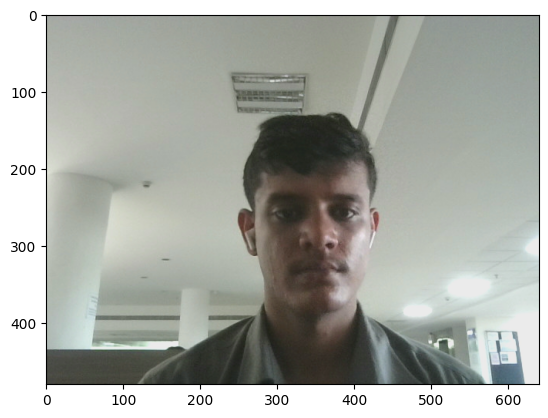

In [24]:
plt.imshow(cv2.cvtColor(frame , cv2.COLOR_BGR2RGB))

In [25]:
#Path for the extracted data which are gooing to be our numpy arrays
DATA_PATH = os.path.join('MP_Data') 

#Actions to be detected 
actions = np.array(['hello' ,  'Thankyou' , 'ILoveYou'])

no_sequences = 30 #Thirty videos worth of data
sequence_length = 30 #Videos are going to be thirty frames in length


#We are going to create a folder per action and these actions are gonna have one folder for on sequence  from 0 to 29


In [26]:
for action in actions : 
    for sequence in range(no_sequences):
        try: 
            os.makedirs(os.path.join(DATA_PATH , action , str(sequence)))
        except: 
            pass

In [27]:
cap = cv2.VideoCapture(0)
if not cap.isOpened():
    raise RuntimeError("COuld not open webcam")
frame_count = 0

with mp_holistic.Holistic(
    min_detection_confidence = 0.5 , 
    min_tracking_confidence = 0.5,
    model_complexity = 0
) as holistic:
    

    #Loop through actions 
    for action in actions:
        #Loop through sequence /videos
        for sequence in range(no_sequences):
            #Loop through video length aka sequence length
            for frame_num in range(sequence_length):

                #Read feed        
                ret , frame = cap.read()
                if not ret: 
                    break
                    
                image, results = mediapipe_detection(frame , holistic)

                #Draw landmarks
                draw_styled_landmarks(image, results)
                    
                #Apply wait logic
                if frame_num == 0:
                    cv2.putText(image , 'STARTING COLLECTION' , (120,200),
                                cv2.FONT_HERSHEY_SIMPLEX , 1, (0,255,0) , 4, cv2.LINE_AA)
                    cv2.putText(image, 'Collecting frames for {} video number {}'.format(action,sequence) , (15,12),
                                cv2.FONT_HERSHEY_SIMPLEX , 0.5 , (0,0,255)  ,1 , cv2.LINE_AA)
                    cv2.waitKey(2000)
                        
                else :
                    cv2.putText(image, 'Collecting Frames for {} video number {}'.format(action, sequence), (15,12) , 
                                cv2.FONT_HERSHEY_SIMPLEX , 0.5 , (0,0,255) , 1 , cv2.LINE_AA) 
                        
                #NEW Export Keyoints 
                keypoints = extract_keypoints(results)
                npy_path = os.path.join(DATA_PATH , action , str(sequence) , str(frame_num))
                np.save(npy_path , keypoints)
                #Show to screen
                cv2.imshow('Feed' , image)

                #Break 
                if cv2.waitKey(10) & 0xFF == ord('q'):
                    break

    cap.release()
    cv2.destroyAllWindows()   

In [28]:
cap.release()
cv2.destroyAllWindows()

In [29]:
import tensorflow as tf
import sklearn

print("TensorFlow:", tf.__version__)
print("Sklearn working")

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorial

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
import sklearn
print(sklearn.__version__)

In [ ]:
import tensorflow
print(tensorflow.__version__)